In [138]:
import numpy as np
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import pickle
import csv
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import seaborn as sns
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.rdm import RDMs
from glob import glob
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

In [98]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [99]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

## Create mask for RDMs

### Using subject fMRI data to create mask

    Avoid using subject data that included eyeball voxels. Subjects 4, 5, 10, 11, 15, 16, and 17 fMRI data do not contain eyeball voxels. 

c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "



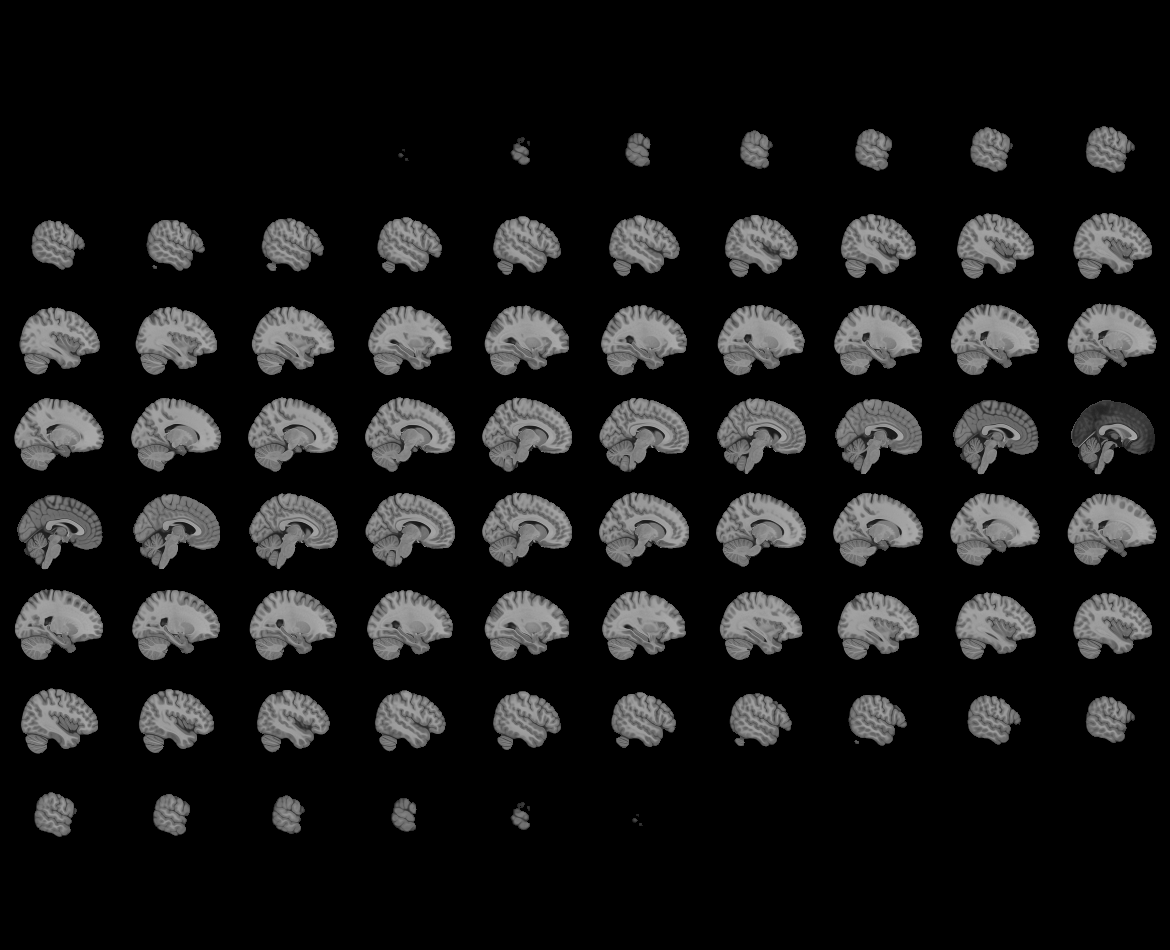
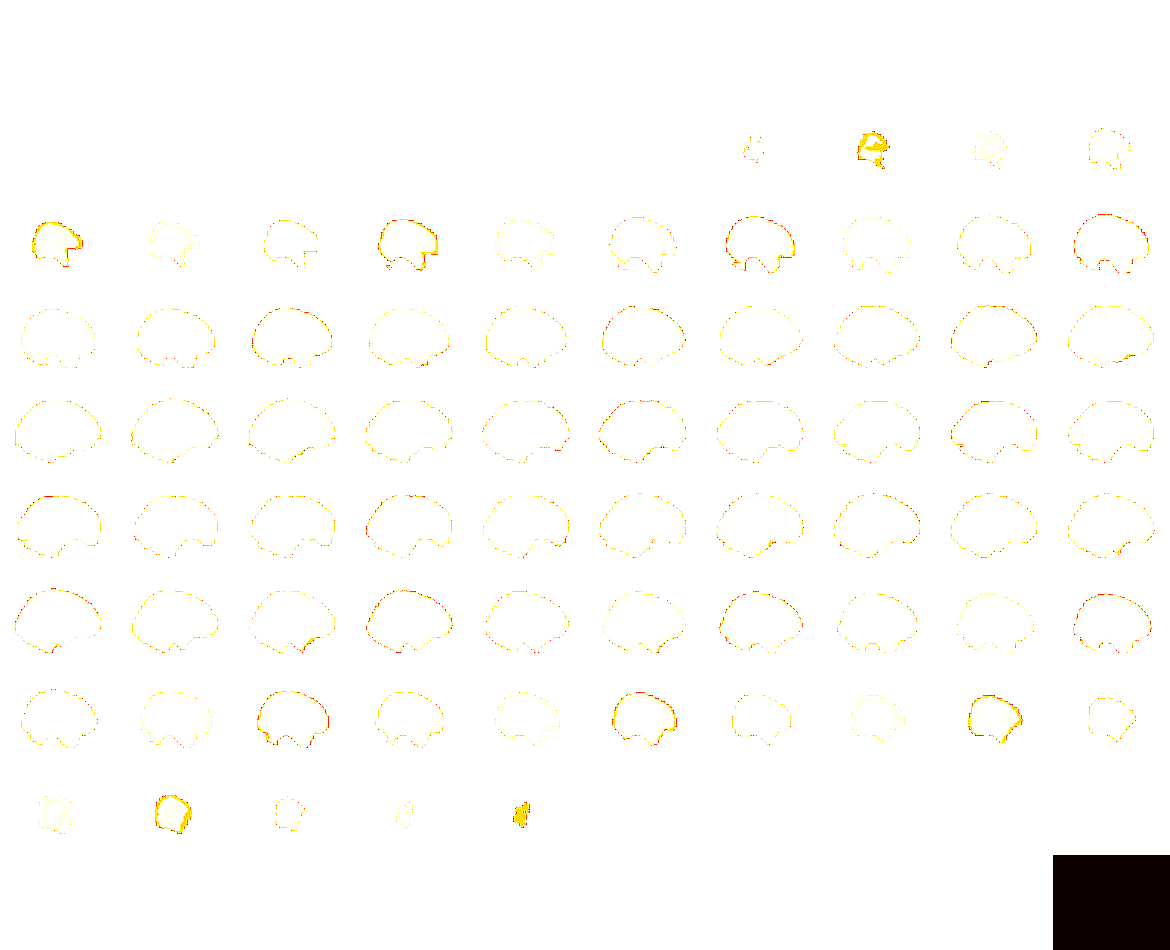

In [101]:
stimuli = ['Pl','Nt','Up']
no_eyeballvoxel_subjects = [4,5,10,11,15,16,17]

sub_mask_list = []
for s, sub in enumerate(no_eyeballvoxel_subjects):

    mask_list = []
    for i, stim in enumerate(stimuli):
        image_path = '../IAPS_fMRI_RSA/fMRI/{}{}.mat'.format(stim,sub-1)
        # load one image to get the dimensions and make the mask
        image_file = sio.loadmat(image_path)
        mask_file = image_file['{}'.format(stim)] #(153594, 100)
        mask_list.append(mask_file)

    allmask = np.hstack(mask_list)
    mask_sum = np.sum(allmask, axis = 1)
    sub_mask_list.append(mask_sum)

allsub_mask = np.vstack(sub_mask_list)
allsub_mask_sum = np.sum(allsub_mask, axis = 0)
mask_flat = (~np.isnan(allsub_mask_sum)).astype(int)
x, y, z = 53,63,46
mask_reshape = mask_flat.reshape(z, y, x)
mask = np.moveaxis(mask_reshape, [0,1,2], [2,1,0])

tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)
mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

## Create searchlight centers and neighbours

In [102]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 59159/59159 [00:24<00:00, 2373.75it/s]


Found 56949 searchlights


## Load fMRI RDMs

### Stimuli

In [103]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
stim_Nt = stim_file[0:100]
stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [104]:
stim_Nt_id = pd.DataFrame(stim_Nt[['type']]).T
stim_Nt_id.shape
stim_Pl_id = pd.DataFrame(stim_Pl[['type']]).T
stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['type']]).T
stim_Up_id.shape
print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [105]:
allsub_avg = []

subjects = 20
for i in range(subjects):
    sub_avg = []
    #Pleasant
    mat_name_Pl = '../IAPS_fMRI_RSA/fMRI/Pl{}.mat'.format(i+1)
    mat_file_Pl = sio.loadmat(mat_name_Pl)
    data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    data_Pl_reshape = data_Pl.reshape(46, 63, 53, 100)
    data_Pl_reorder = np.moveaxis(data_Pl_reshape, [0,1,2,3], [2,1,0,3])
    data_Pl_reorder_flat = np.reshape(data_Pl_reorder, (153594,100))
    data_Pl_df = pd.DataFrame(data_Pl_reorder_flat) #(153594, 100)
    Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    Pl_df = Pl_df.T

    #Neutral
    mat_name_Nt = '../IAPS_fMRI_RSA/fMRI/Nt{}.mat'.format(i+1)
    mat_file_Nt = sio.loadmat(mat_name_Nt)
    data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    data_Nt_reshape = data_Nt.reshape(46, 63, 53, 100)
    data_Nt_reorder = np.moveaxis(data_Nt_reshape, [0,1,2,3], [2,1,0,3])
    data_Nt_reorder_flat = np.reshape(data_Nt_reorder, (153594,100))
    data_Nt_df = pd.DataFrame(data_Nt_reorder_flat) #(153594, 100)
    Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    Nt_df = Nt_df.T

    #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_reshape = data_Up.reshape(46, 63, 53, 100)
    data_Up_reorder = np.moveaxis(data_Up_reshape, [0,1,2,3], [2,1,0,3])
    data_Up_reorder_flat = np.reshape(data_Up_reorder, (153594,100))
    data_Up_df = pd.DataFrame(data_Up_reorder_flat) #(153594, 100)
    Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    Up_df = Up_df.T

    sub_df = pd.concat([Pl_df, Nt_df, Up_df]) #(153595,300)
    sub_df['type'] = pd.Categorical(sub_df['type'], ["Pl","Nt","Up" ])
    sub_avg_df = sub_df.groupby('type').mean() #(3, 153595) 
    sub_avg_df2 = sub_avg_df.reset_index(drop=True) #(3, 153594)

    allsub_avg.append(sub_avg_df2)
    # sub_avg = np.nan_to_num(sub_avg)

In [107]:
allsub_avg[1].shape

(3, 153594)

### Plot one emotion type out of the three emotions 

c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



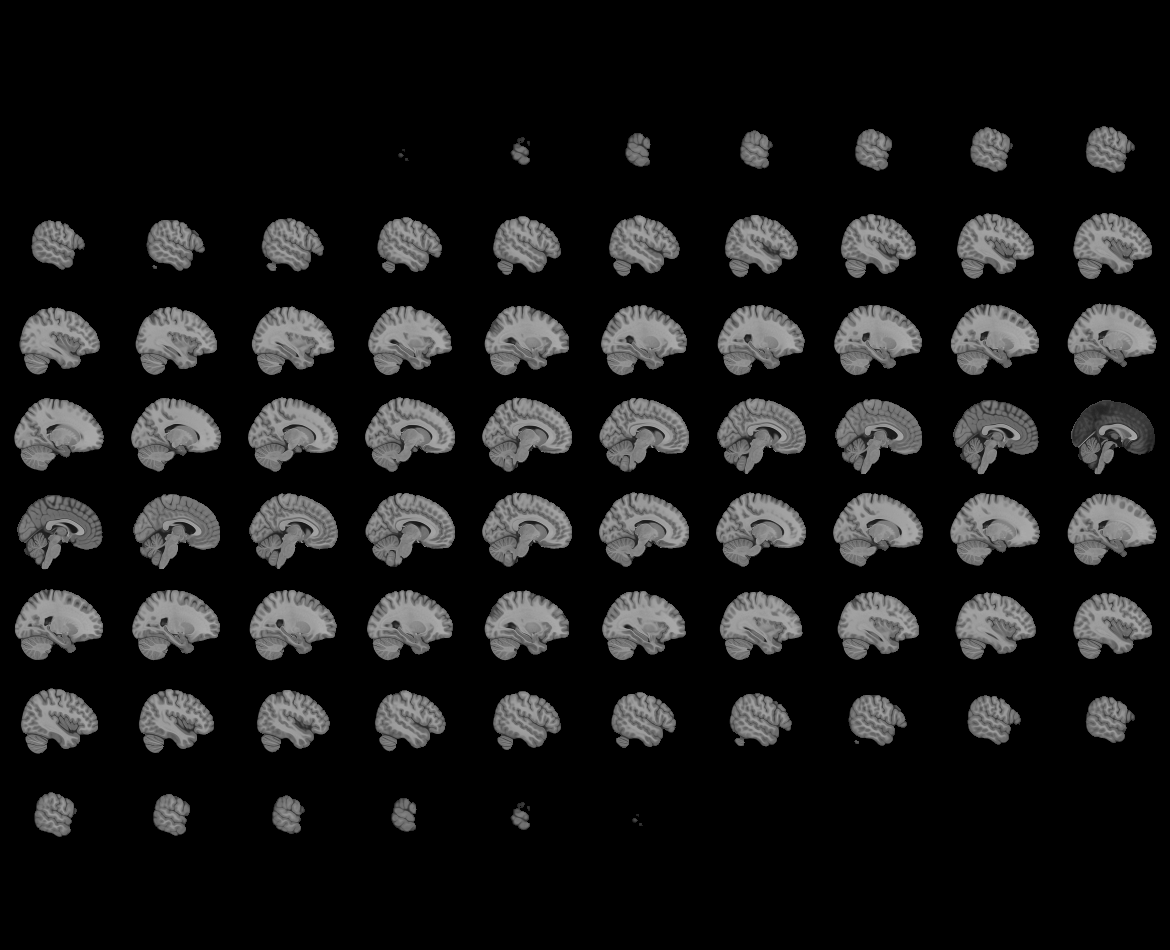
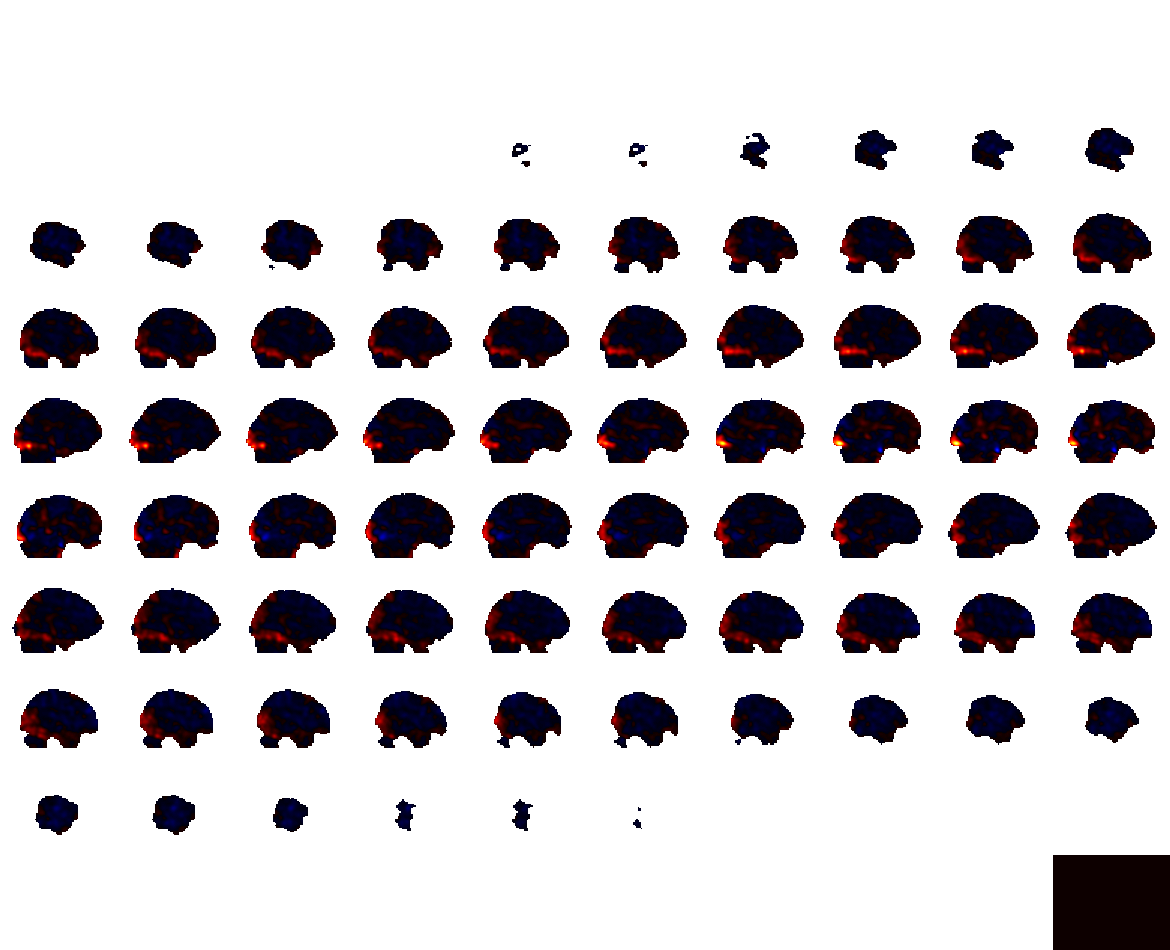

In [108]:
plot_slice = np.array(allsub_avg[4])[0,:] # subject 5, Pleasant
plot_slice_3d = plot_slice.reshape(53, 63, 46)
plot_neural_rdm_emo1 = new_img_like(tmp_img, plot_slice_3d)
view = plotting.view_img(plot_neural_rdm_emo1)
view

### Export neural RDM

In [106]:
dbfile= open('./outputs/20sub_nerual_3emo_rdm2', 'ab')
pickle.dump(allsub_avg, dbfile)                     
dbfile.close()

### Import neural RDM

In [19]:
dbfile = open('./outputs/20sub_nerual_3emo_rdm2', 'rb')     
allsub_avg = pickle.load(dbfile)

## Load Behavioral RDMs

In [109]:
rdm_behavioral = pd.read_csv("../IAPS_behavioral_RDM/rdm_behavioral_emo.csv",  index_col=0)
rdm_behavioral = np.array(rdm_behavioral)
behavioral_model = ModelFixed('Behavioral RDM', upper_tri(rdm_behavioral))

In [110]:
rdm_behavioral.shape

(3, 3)

## 2. Searchlight analysis

In [111]:
eval_score_list = []
RDM_brain_list = []

for i in range(20):
    subj_data = allsub_avg[i]
    subj_data_2d = np.nan_to_num(subj_data)

    image_value = np.arange(3)
    SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

    eval_results = evaluate_models_searchlight(SL_RDM, behavioral_model, eval_fixed, method='corr', n_jobs=3)
    # get the evaulation score for each voxel
    # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
    eval_score = [np.float(e.evaluations) for e in eval_results]
    # Create an 3D array, with the size of mask, and
    x, y, z = mask.shape
    RDM_brain = np.zeros([x*y*z])
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape([x, y, z])

    eval_score_list.append(eval_score)
    RDM_brain_list.append(RDM_brain)



Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:27<00:00, 2053.63it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22244\2750872992.py:14: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eval_score = [np.float(e.evaluations) for e in eval_results]
Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:22<00:00, 2535.00it/s]


### Export/Load searchlight results

In [112]:
# Export
# Save the evaluation scores and RDMs.

# pd.DataFrame(eval_score_list).to_csv("./outputs/20sub_SL_eval_score_3emo_corr2.csv")
# dbfile= open('./outputs/20sub_SL_rdm_brain_3emo_corr2', 'ab')
# pickle.dump(RDM_brain_list, dbfile)                     
# dbfile.close()


In [30]:
# Import
# eval_score_df = pd.read_csv("./outputs/20sub_SL_eval_score_3emo2.csv")
# eval_score_list = eval_score_df.values.tolist()
# dbfile = open('./outputs/20sub_SL_rdm_brain_3emo2', 'rb')     
# RDM_brain_list = pickle.load(dbfile)

## Plot results

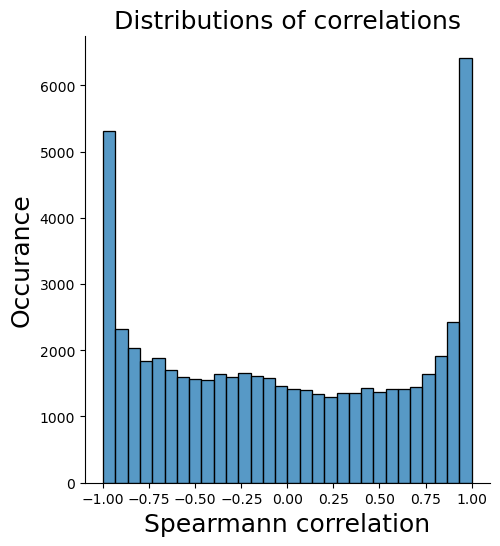

In [113]:
sns.displot(eval_score_list[4])
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

In [32]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score_list[4], 99)
plot_img = new_img_like(tmp_img, RDM_brain_list[4])
cmap = RDMcolormapObject()
coords = range(-100, 100, 5)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\displays\_slicers.py:382: UserWarning: empty mask
  get_mask_bounds(new_img_like(img, not_mask, affine))


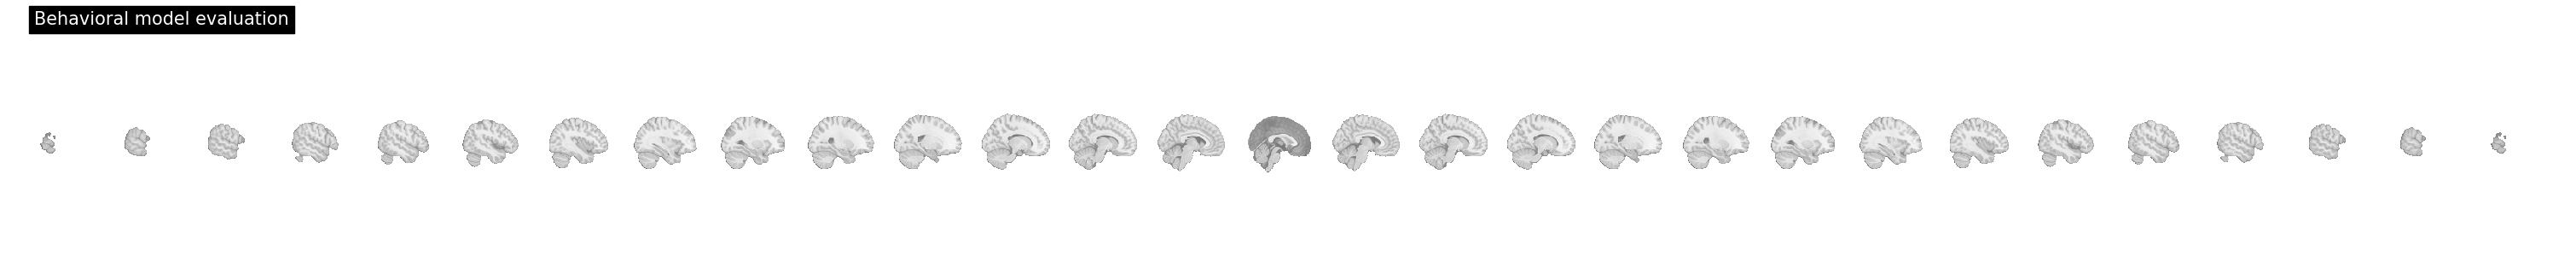

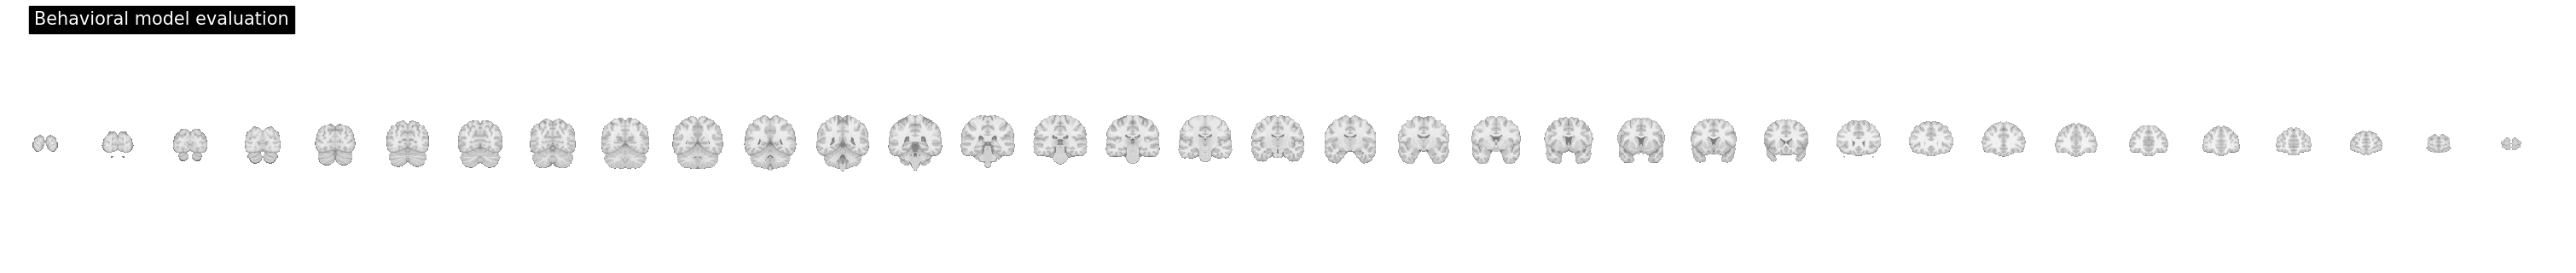

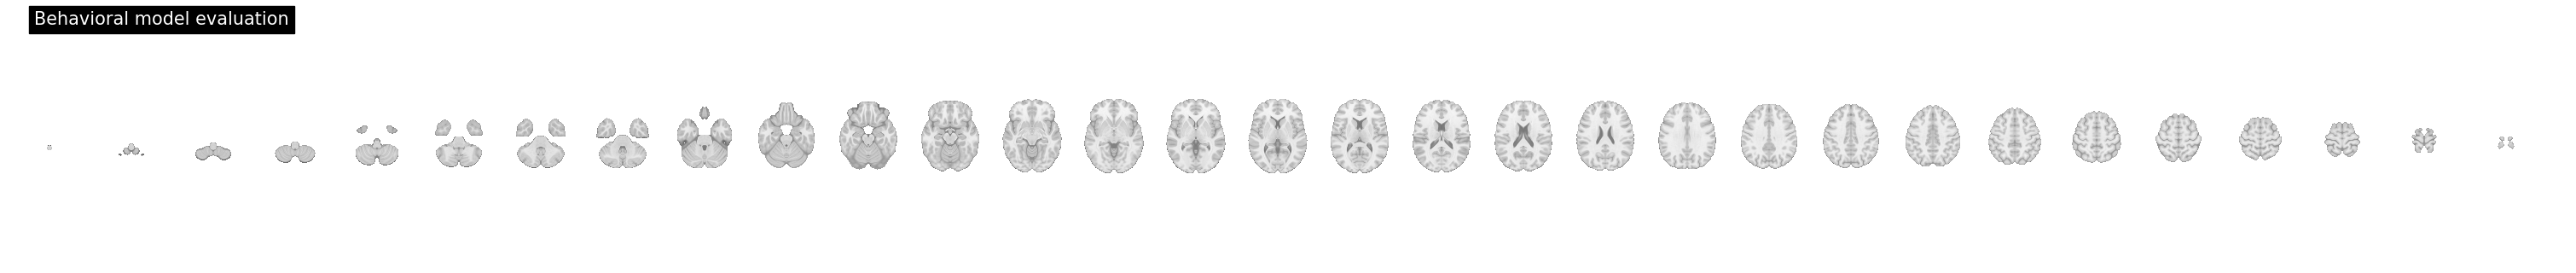

In [33]:
fig_x = plt.figure(figsize=(30, 3))
display_x = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='x', draw_cross=False, figure=fig_x,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_y = plt.figure(figsize=(30, 3))
display_y = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='y', draw_cross=False, figure=fig_y,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_z = plt.figure(figsize=(30, 3))        
display_z = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='z', draw_cross=False, figure=fig_z,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

# # Create new figure and three subplots, sharing axes
# fig3, (ax1, ax2, ax3) = plt.subplots(3,1,sharey=True, sharex=True,figsize=(60,12))        
# fig3.show()
plt.show()

In [64]:
RDM_brain_list[1].shape

(53, 63, 46)

## Across subjects analysis

In [114]:
for i in range(20):
    sl_max = np.max(RDM_brain_list[i])
    sl_min = np.min(RDM_brain_list[i])
    sl_mid = np.median(RDM_brain_list[i])
    print("Subject{} max:{}, mid:{}, min:{}".format(i+1,sl_max,sl_mid, sl_min ))

Subject1 max:0.9999999895652183, mid:0.0, min:-0.999999998330775
Subject2 max:0.9999999999108148, mid:0.0, min:-0.9999999999495823
Subject3 max:0.9999999275481777, mid:0.0, min:-0.9999999827601167
Subject4 max:0.9999999853369325, mid:0.0, min:-0.9999999992668862
Subject5 max:0.9999999969654404, mid:0.0, min:-0.9999999999386767
Subject6 max:0.9999999998725326, mid:0.0, min:-0.9999999935604271
Subject7 max:0.9999998816144566, mid:0.0, min:-0.9999999999850779
Subject8 max:0.9999999997416534, mid:0.0, min:-0.9999999995091245
Subject9 max:0.9999976461799672, mid:0.0, min:-0.999999999555672
Subject10 max:0.9999999957462593, mid:0.0, min:-0.999999999789474
Subject11 max:0.9999999983686807, mid:0.0, min:-0.9999999944679169
Subject12 max:0.9999999998250179, mid:0.0, min:-0.9999999872346642
Subject13 max:0.9999999974267377, mid:0.0, min:-0.999999999660994
Subject14 max:0.9999999998671313, mid:0.0, min:-0.9999999997589631
Subject15 max:0.9999999999438506, mid:0.0, min:-0.9999999999116865
Subject1

In [129]:
RDM_brain_bin_list = []

for i in range(20):
    RDM_brain_bin = np.where(RDM_brain_list[i] > 0.9, 1, 0)
    RDM_brain_bin_list.append(RDM_brain_bin)

In [130]:
for i in range(20):
    sl_max = np.max(RDM_brain_bin_list[i])
    sl_min = np.min(RDM_brain_bin_list[i])
    print("Subject{} max:{}, min:{}".format(i+1,sl_max,sl_min ))

Subject1 max:1, min:0
Subject2 max:1, min:0
Subject3 max:1, min:0
Subject4 max:1, min:0
Subject5 max:1, min:0
Subject6 max:1, min:0
Subject7 max:1, min:0
Subject8 max:1, min:0
Subject9 max:1, min:0
Subject10 max:1, min:0
Subject11 max:1, min:0
Subject12 max:1, min:0
Subject13 max:1, min:0
Subject14 max:1, min:0
Subject15 max:1, min:0
Subject16 max:1, min:0
Subject17 max:1, min:0
Subject18 max:1, min:0
Subject19 max:1, min:0
Subject20 max:1, min:0


In [131]:
RDM_brain_bin_array = np.stack(RDM_brain_bin_list, axis=0)
# RDM_brain_bin_array.shape
SL_threshcount = np.sum(RDM_brain_bin_array, axis = 0)
sl_bin_max = np.max(SL_threshcount)
sl_bin_min = np.min(SL_threshcount)
print("max:{}, min:{}".format(sl_bin_max,sl_bin_min ))

max:15, min:0


c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



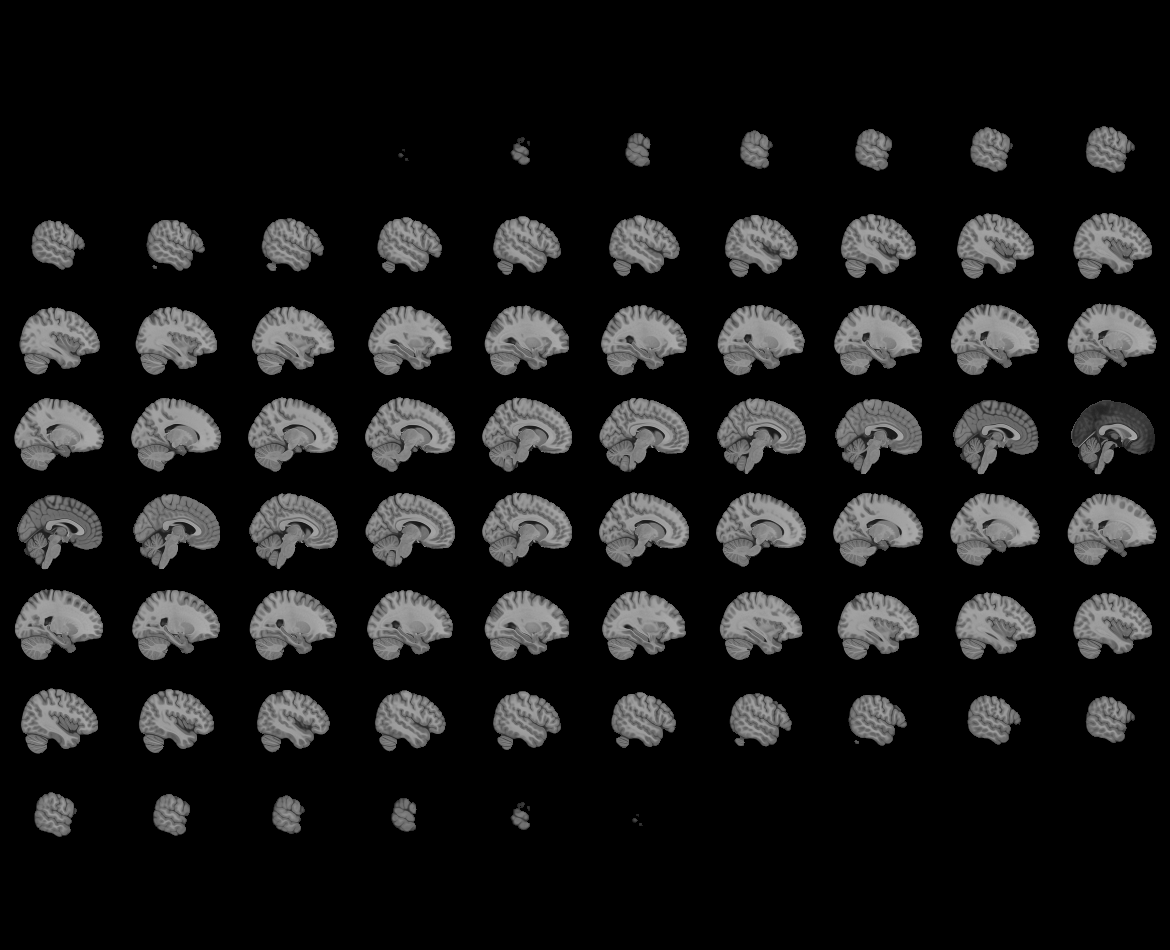
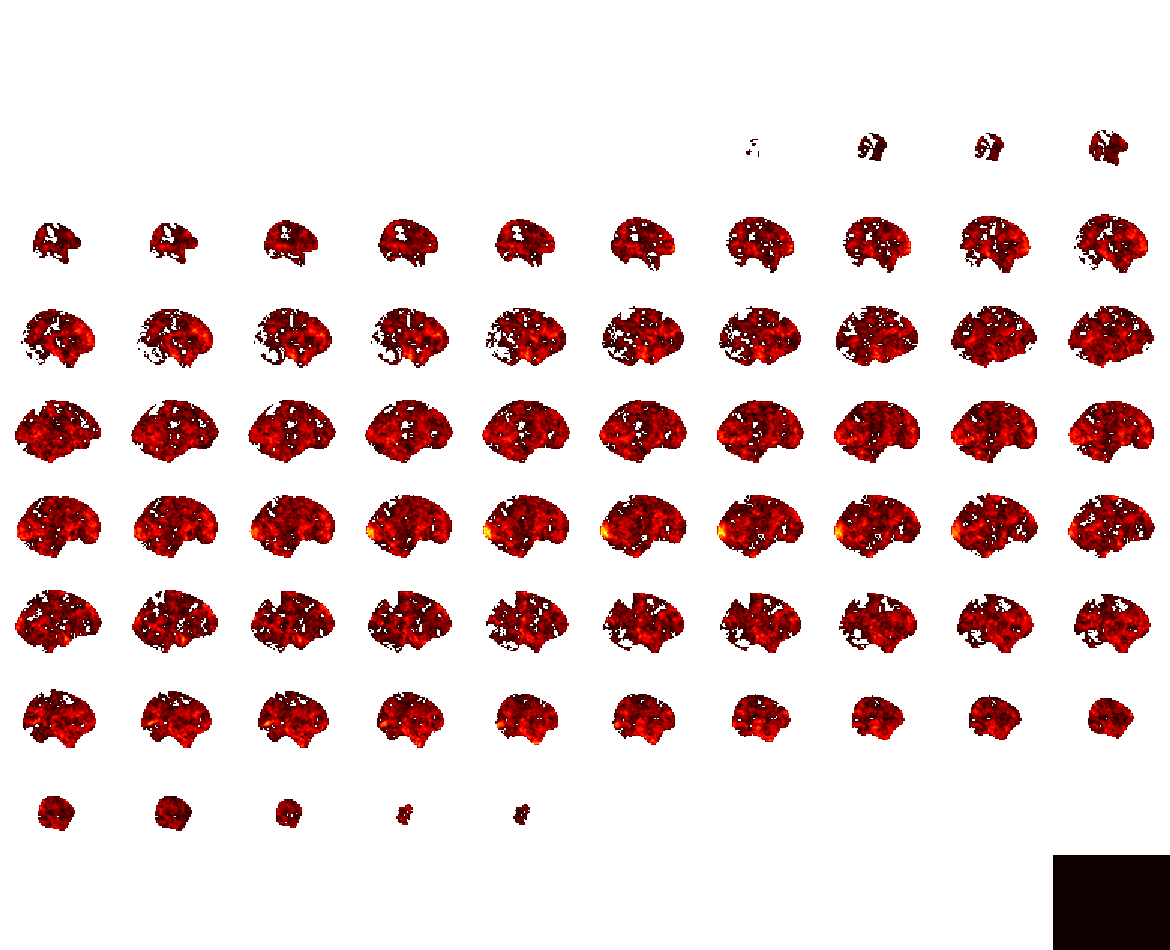

In [132]:
plot_SL_img = new_img_like(tmp_img, SL_threshcount)
view = plotting.view_img(plot_SL_img)
view

## Group analysis
When these results are used for group analysis across multiple subjects, it may be good to Fisher-transform the correlation values, so that they are more normally distributed.

### Fisher z transformation

In [135]:
eval_score_array = np.array(eval_score_list)
seed_to_voxel_correlations_fisher_z = np.arctanh(eval_score_array)

### t-test

In [141]:
t_stat_list = []
p_value_list = []

for i in range(seed_to_voxel_correlations_fisher_z.shape[-1]):
    t_statistic, p_value = stats.ttest_1samp(a=seed_to_voxel_correlations_fisher_z[:,i], popmean=0) 
    t_stat_list.append(t_statistic)
    p_value_list.append(p_value)

t_stat_array = np.array(t_stat_list)
p_value_array = np.array(p_value_list)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22244\1302180378.py:4: RuntimeWarning: divide by zero encountered in log10
  neg_log_p = np.log10(p_value_brain) * (-1)
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



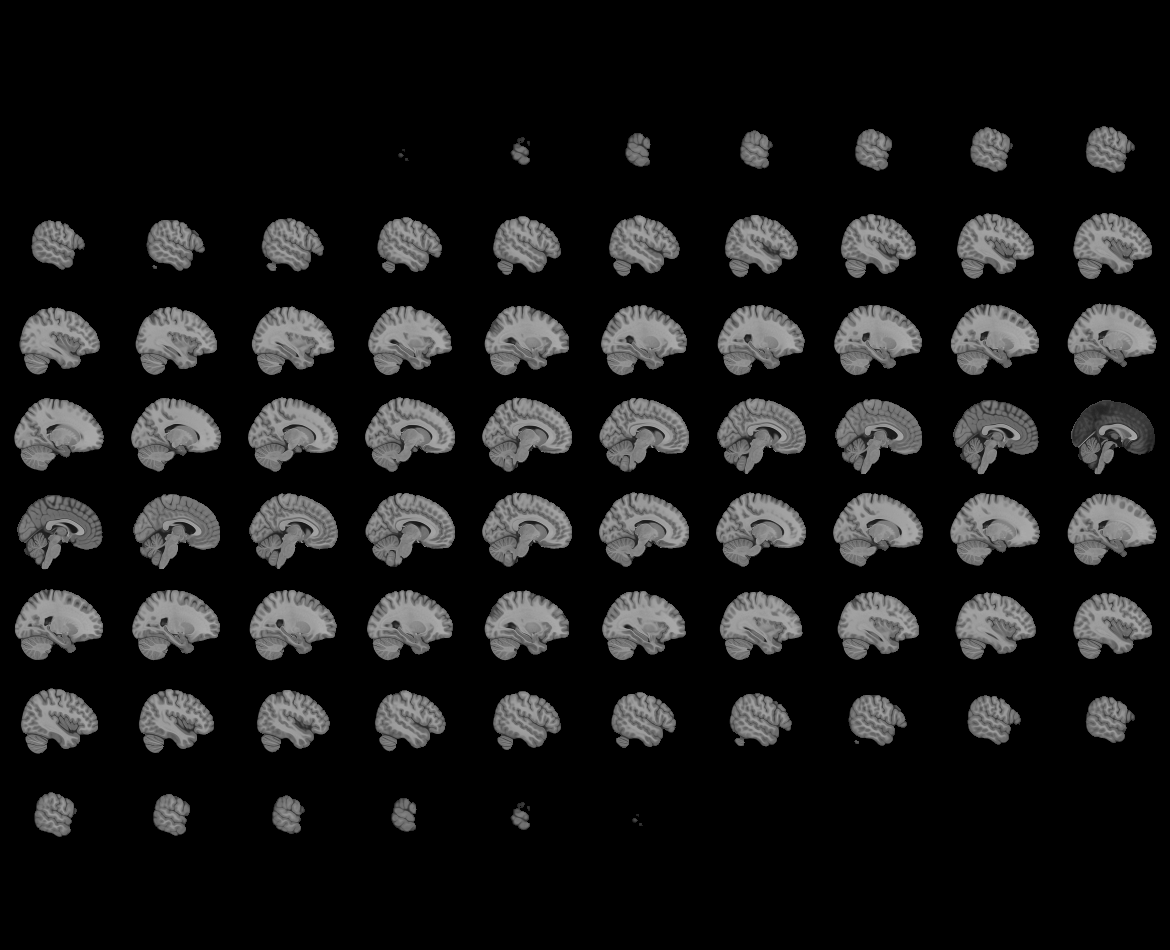
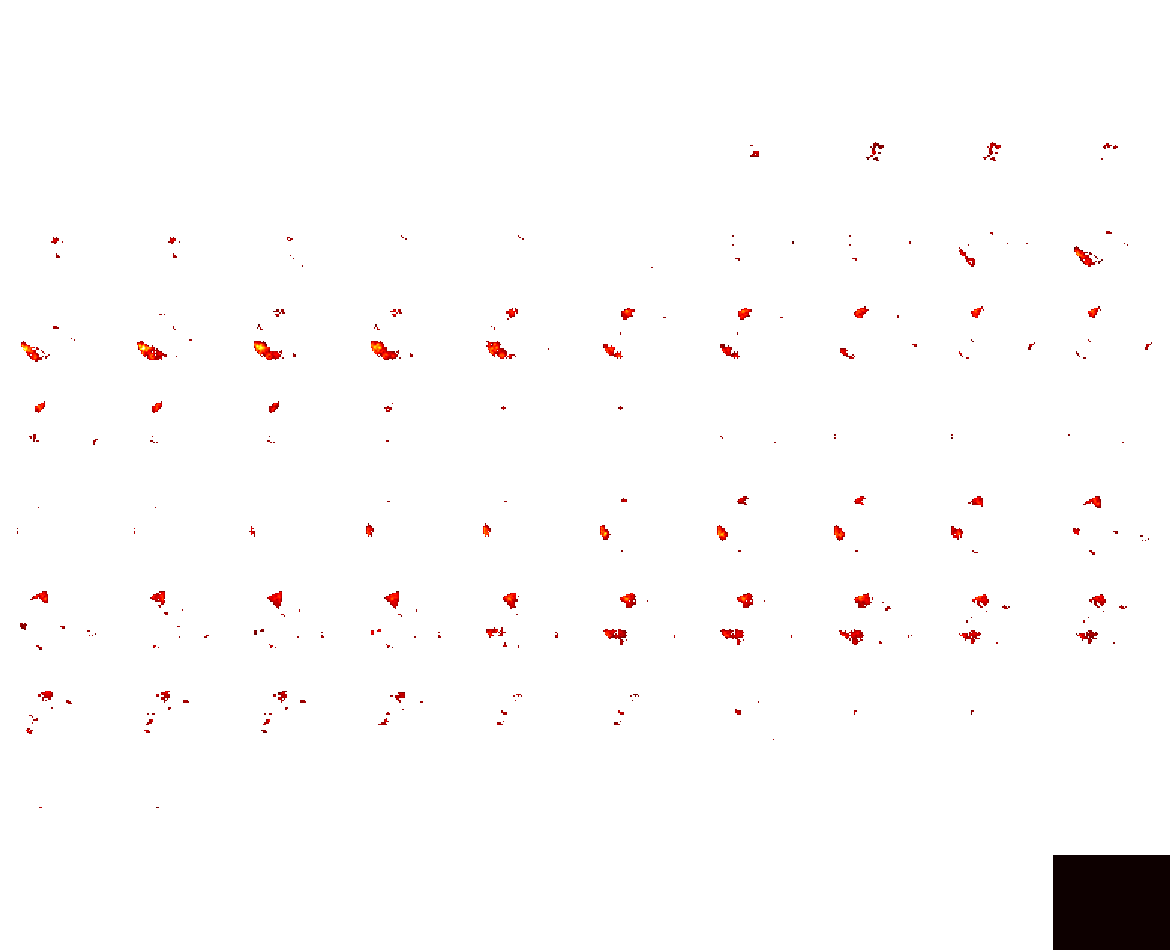

In [143]:
x, y, z = mask.shape
p_value_brain = np.empty([x*y*z])
p_value_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = p_value_array
neg_log_p = np.log10(p_value_brain) * (-1)
neg_log_p_brain = neg_log_p.reshape([x, y, z])

plot_neglog_p_img = new_img_like(tmp_img, neg_log_p_brain)
view = plotting.view_img(plot_neglog_p_img, threshold = 2)
view

### Corrected p-values

In [146]:
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.001, method='indep', is_sorted=False)
x, y, z = mask.shape
corrected_p_value_array = np.empty([x*y*z])
corrected_p_value_array[list(SL_RDM.rdm_descriptors['voxel_index'])] = corrected_pvalue
neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)
neg_log_corrected_p_brain = neg_log_corrected_p.reshape([x, y, z])

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22244\2890858288.py:5: RuntimeWarning: divide by zero encountered in log10
  neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)


c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_clone\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



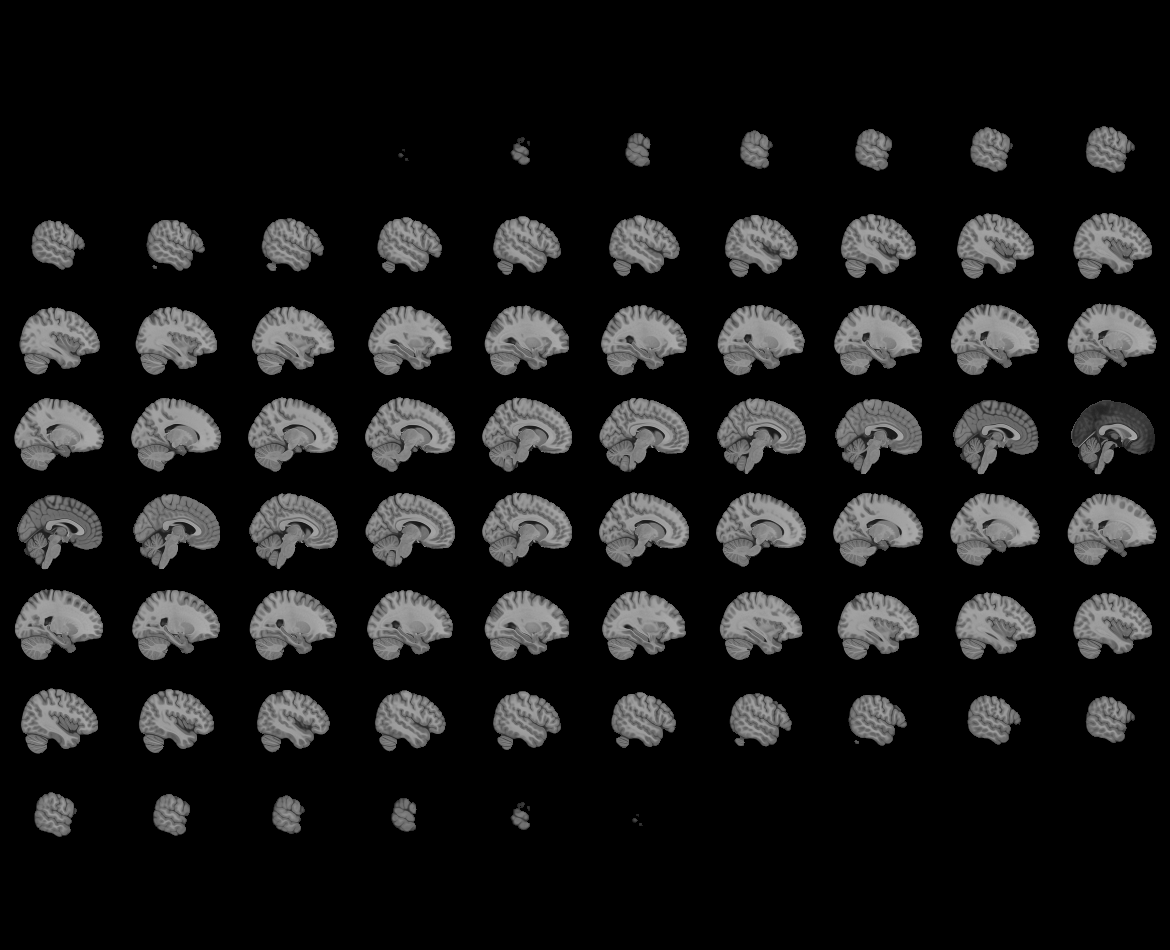
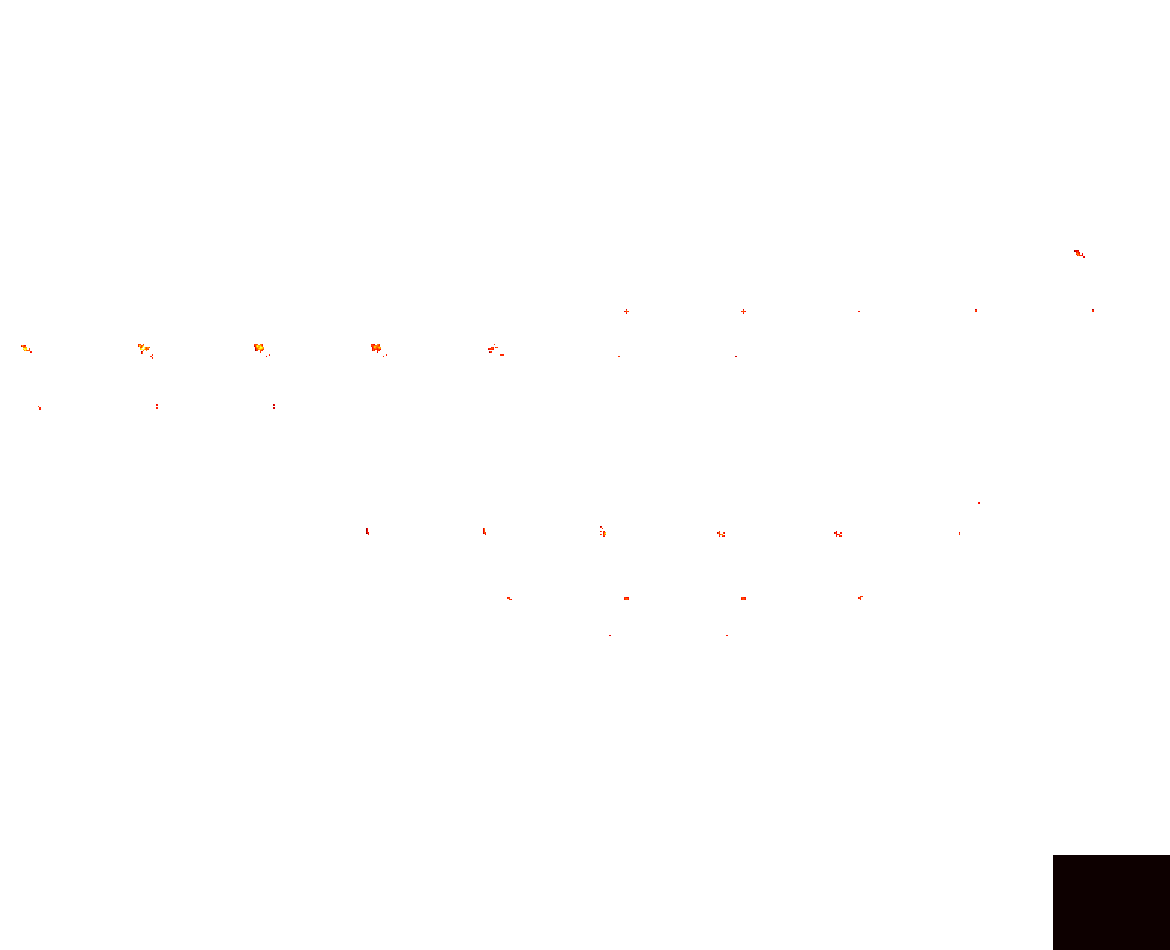

In [147]:
plot_corrected_neglog_pvalue_img = new_img_like(tmp_img, neg_log_corrected_p_brain)
view = plotting.view_img(plot_corrected_neglog_pvalue_img, threshold = 2)
view

In [148]:
nib.save(plot_corrected_neglog_pvalue_img, os.path.join("C:/Users/yujunchen/Dropbox (UFL)/Searchlight results", 'beh3.nii.gz'))